In [1]:
import sys, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from datetime import datetime, timedelta

# Locate premier_league/ regardless of where Jupyter was launched
_here = Path.cwd()
if not (_here / 'outputs.ipynb').exists():
    for _c in [_here / 'premier_league',
               _here / 'non_penalty_bayes' / 'premier_league',
               _here / 'team_strength' / 'non_penalty_bayes' / 'premier_league']:
        if _c.exists():
            os.chdir(_c)
            break

NOTEBOOK_DIR = Path.cwd().resolve()
NP_BAYES_DIR = str(NOTEBOOK_DIR.parent)
sys.path.insert(0, NP_BAYES_DIR)

REPO_ROOT = str(NOTEBOOK_DIR.parents[4])
sys.path.insert(0, os.path.join(REPO_ROOT, 'viz'))

from src.data_utils import load_and_process_data, load_football_data, create_weighted_scoreline_data, prepare_model_data
from src.model import build_and_sample_model
from src.simulation import (run_multiple_seasons, load_actual_results,
                             get_actual_standings, form_net_rating,
                             get_last_result, get_form_string, rank_arrow)
from pl_combined_table import render_combined_table
from pl_html_export import render_html_export
from pl_evo_chart import render_evo_chart
from pl_scatter import render_scatter
from logos import TEAM_LOGOS as team_logos

LEAGUE  = 'Premier_League'
SEASON  = '2025-2026'

DB_PATH = os.path.join(REPO_ROOT, 'infra', 'data', 'db', 'fotmob.db')

# Sampling
N_SAMPLES           = 20000
N_TUNE              = 10000
N_SAMPLES_EVOLUTION = 2000
N_TUNE_EVOLUTION    = 1000

# Blend weights
DECAY_RATE   = 0.0018
GOALS_WEIGHT = 0.25
XG_WEIGHT    = 0.50
PSXG_WEIGHT  = 0.15
EPV_WEIGHT   = 0.10

BASELINE_HOME_PENS = 0.157 * 0.78
BASELINE_AWAY_PENS = 0.101 * 0.78

# ── Form window config (update each week) ────────────────────────────────────
FORM_END      = '2026-04-06'
FORM_START    = '2025-11-24'
FORM_PREV_END = (datetime.strptime(FORM_END, '%Y-%m-%d') - timedelta(weeks=1)).strftime('%Y-%m-%d')


print(f'CWD:          {NOTEBOOK_DIR}')
print(f'DB:           {DB_PATH}')
print(f'FORM_END:     {FORM_END}')
print(f'FORM_PREV_END:{FORM_PREV_END}')

CWD:          /Users/admin/dev/algobetting/algo/models/team_strength/non_penalty_bayes/premier_league
DB:           /Users/admin/dev/algobetting/infra/data/db/fotmob.db
FORM_END:     2026-04-06
FORM_PREV_END:2026-03-30


## Current ratings — full season

In [2]:
df, team_mapping, n_teams = load_and_process_data(
    db_path=DB_PATH, league=LEAGUE, season=SEASON,
    decay_rate=DECAY_RATE, goals_weight=GOALS_WEIGHT,
    xg_weight=XG_WEIGHT, psxg_weight=PSXG_WEIGHT, epv_weight=EPV_WEIGHT,
)
team_names = list(team_mapping.keys())
print(f'{n_teams} teams, {df["match_id"].nunique()} matches')

20 teams, 309 matches


In [3]:
from manual_priors import MANUAL_ATT_PRIORS, MANUAL_DEF_PRIORS

_, trace = build_and_sample_model(
    df, n_teams, trace=N_SAMPLES, tune=N_TUNE,
    team_mapping=team_mapping,
    manual_att_priors=MANUAL_ATT_PRIORS,
    manual_def_priors=MANUAL_DEF_PRIORS,
)
print('Done.')

Done.


In [4]:
posterior = trace.posterior
att  = posterior['att_str'].values.reshape(-1, n_teams)
defn = posterior['def_str'].values.reshape(-1, n_teams)
hadv = posterior['home_adv'].values.reshape(-1)
base = posterior['baseline'].values.reshape(-1)

ratings = pd.DataFrame({
    'team':     team_names,
    'att_mean': att.mean(axis=0).round(3),
    'att_sd':   att.std(axis=0).round(3),
    'att_lo':   np.percentile(att, 5,  axis=0).round(3),
    'att_hi':   np.percentile(att, 95, axis=0).round(3),
    'def_mean': defn.mean(axis=0).round(3),
    'def_sd':   defn.std(axis=0).round(3),
    'def_lo':   np.percentile(defn, 5,  axis=0).round(3),
    'def_hi':   np.percentile(defn, 95, axis=0).round(3),
})
ratings['net'] = (ratings['att_mean'] - ratings['def_mean']).round(3)
ratings = ratings.sort_values('net', ascending=False).reset_index(drop=True)
ratings

,team,att_mean,att_sd,att_lo,att_hi,def_mean,def_sd,def_lo,def_hi,net
0,Arsenal,0.262,0.144,0.018,0.491,-0.491,0.193,-0.816,-0.179,0.753
1,Man City,0.292,0.142,0.059,0.522,-0.168,0.174,-0.464,0.110,0.460
2,Liverpool,0.248,0.145,0.011,0.483,-0.103,0.161,-0.372,0.158,0.351
3,Chelsea,0.243,0.146,-0.002,0.475,-0.005,0.162,-0.281,0.252,0.248
4,Man United,0.178,0.147,-0.071,0.414,-0.036,0.159,-0.303,0.222,0.214
5,Brighton,0.054,0.157,-0.205,0.302,-0.083,0.166,-0.362,0.183,0.137
6,Brentford,0.080,0.154,-0.178,0.325,-0.054,0.165,-0.335,0.211,0.134
7,Newcastle,0.074,0.151,-0.179,0.320,-0.018,0.160,-0.285,0.243,0.092
8,Aston Villa,0.037,0.157,-0.226,0.293,0.015,0.155,-0.242,0.263,0.022
9,Crystal Palace,-0.048,0.161,-0.317,0.214,-0.041,0.164,-0.313,0.227,-0.007


/Users/admin/dev/algobetting/viz/pl_scatter.py:129: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Roboto.
  plt.tight_layout()
/Users/admin/dev/algobetting/viz/pl_scatter.py:129: UserWarning: Glyph 8593 (\N{UPWARDS ARROW}) missing from font(s) Roboto.
  plt.tight_layout()
/Users/admin/dev/algobetting/viz/pl_scatter.py:133: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Roboto.
  plt.savefig(save_path, dpi=180, bbox_inches='tight', facecolor='white')
/Users/admin/dev/algobetting/viz/pl_scatter.py:133: UserWarning: Glyph 8593 (\N{UPWARDS ARROW}) missing from font(s) Roboto.
  plt.savefig(save_path, dpi=180, bbox_inches='tight', facecolor='white')
/Users/admin/dev/algobetting/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Roboto.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/admin/dev/algobetting/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py

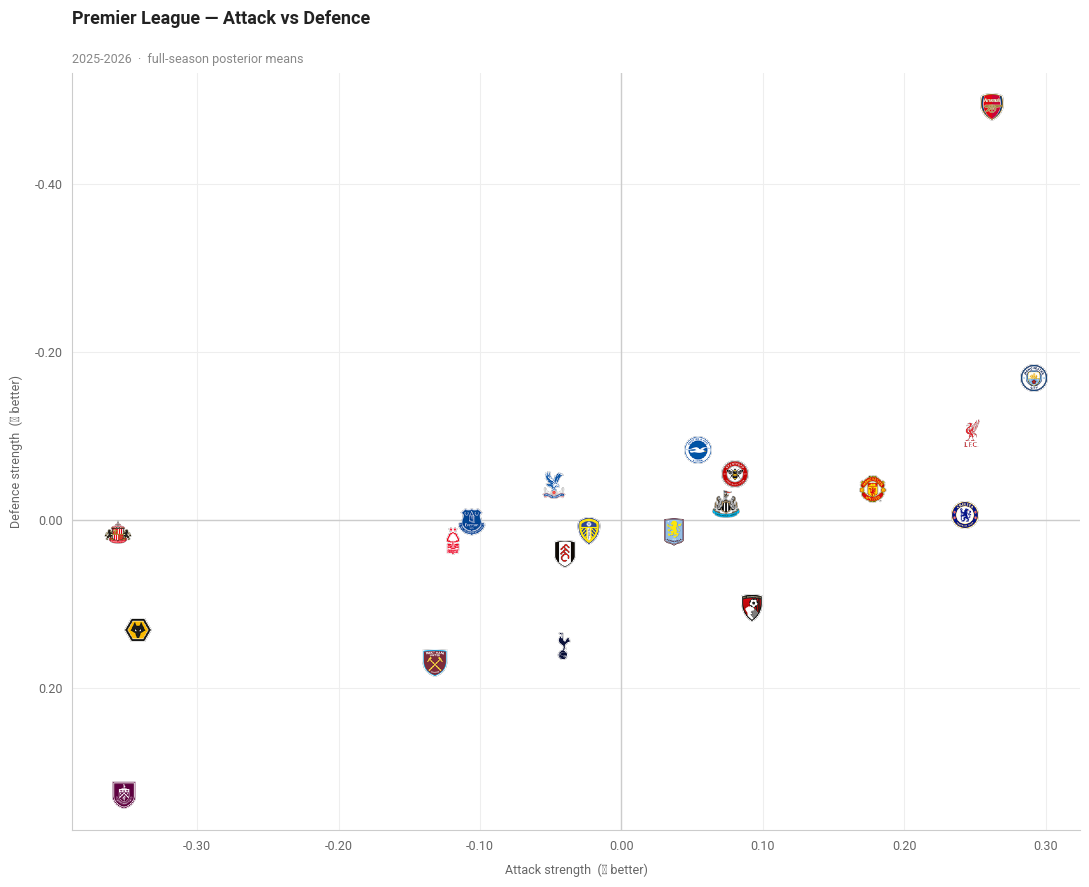

In [5]:
fig = render_scatter(ratings, season=SEASON, league='Premier League',
    save_path=os.path.join(str(NOTEBOOK_DIR), 'outputs', 'rating_scatter.png'))
plt.show()

## Season Projections

In [6]:
# ── ratings_df: Bayesian avg-vs-all-opponents (Jensen's corrected) ────────────
baseline_samples  = trace.posterior['baseline'].values.flatten()
home_adv_samples  = trace.posterior['home_adv'].values.flatten()
att_samples_all   = trace.posterior['att_str'].values.reshape(-1, n_teams)
def_samples_all   = trace.posterior['def_str'].values.reshape(-1, n_teams)
all_teams_list    = list(team_mapping.keys())

team_stats = {t: {'goals_for': 0, 'goals_against': 0, 'matches': 0} for t in all_teams_list}

for home_team in all_teams_list:
    hi = team_mapping[home_team]
    for away_team in all_teams_list:
        if home_team == away_team:
            continue
        ai = team_mapping[away_team]
        home_lam = np.exp(baseline_samples + home_adv_samples
                          + att_samples_all[:, hi] + def_samples_all[:, ai])
        away_lam = np.exp(baseline_samples + att_samples_all[:, ai] + def_samples_all[:, hi])

        hg = home_lam.mean() + BASELINE_HOME_PENS
        ag = away_lam.mean() + BASELINE_AWAY_PENS

        team_stats[home_team]['goals_for']     += hg
        team_stats[home_team]['goals_against'] += ag
        team_stats[home_team]['matches']       += 1
        team_stats[away_team]['goals_for']     += ag
        team_stats[away_team]['goals_against'] += hg
        team_stats[away_team]['matches']       += 1

ratings_df = pd.DataFrame([{
    'team':          t,
    'goals_for':     team_stats[t]['goals_for']     / team_stats[t]['matches'],
    'goals_against': team_stats[t]['goals_against'] / team_stats[t]['matches'],
    'goal_diff':     (team_stats[t]['goals_for'] - team_stats[t]['goals_against']) / team_stats[t]['matches'],
} for t in all_teams_list]).sort_values('goal_diff', ascending=False).reset_index(drop=True)

print(ratings_df.to_string(index=False))

          team  goals_for  goals_against  goal_diff
       Arsenal   1.741130       0.858474   0.882656
      Man City   1.770455       1.140972   0.629482
     Liverpool   1.693772       1.212311   0.481461
       Chelsea   1.678056       1.326328   0.351728
    Man United   1.581168       1.294410   0.286758
      Brighton   1.414357       1.247872   0.166485
     Brentford   1.446462       1.280435   0.166027
     Newcastle   1.435056       1.323259   0.111797
   Aston Villa   1.386880       1.365121   0.021759
Crystal Palace   1.285373       1.303825  -0.018452
   Bournemouth   1.450291       1.480499  -0.030208
         Leeds   1.314532       1.369723  -0.055191
        Fulham   1.289392       1.404157  -0.114765
       Everton   1.217415       1.359156  -0.141741
  Nottm Forest   1.203082       1.387177  -0.184095
     Tottenham   1.281800       1.551710  -0.269910
      West Ham   1.178868       1.587714  -0.408846
    Sunderland   0.973634       1.388109  -0.414475
        Wolv

In [7]:
# ── Load actual results + run 10k simulations ─────────────────────────────────
df_actual = load_actual_results(DB_PATH, LEAGUE, SEASON)
print(f'Actual matches: {len(df_actual)}')

N_SIMS = 10_000
avg_table, position_freq = run_multiple_seasons(
    N_SIMS, trace, team_mapping, df_actual
)
avg_table

Actual matches: 309
Pre-computing xG for 380 fixtures...
  Played: 309   To simulate: 71
Running 10,000 simulations...
  2,000 / 10,000
  4,000 / 10,000
  6,000 / 10,000
  8,000 / 10,000


,team,avg_points,pts_low,pts_high,avg_wins,avg_draws,avg_losses,avg_goals_for,avg_goals_against,avg_xg_for,avg_xg_against,avg_position,title_pct,top5_pct,top8_pct,relegation_pct,avg_goal_difference,avg_xg_difference
1,Arsenal,84.1078,80.034950,88.180650,25.1911,8.5345,4.2744,73.8159,27.9715,66.162943,32.622001,1.0425,95.8,100.0,100.0,0.0,45.8444,33.540942
2,Man City,74.8779,70.197300,79.558500,22.0067,8.8578,7.1355,73.8219,37.4371,67.277279,43.356953,2.0044,4.2,100.0,100.0,0.0,36.3848,23.920326
3,Man United,65.7849,61.409016,70.160784,18.0223,11.7180,8.2597,66.8547,52.1975,60.084388,49.187576,3.6304,0.0,94.3,99.9,0.0,14.6572,10.896812
4,Aston Villa,64.0915,59.749049,68.433951,18.7898,7.7221,11.4881,51.9175,46.3024,52.701446,51.874587,4.2562,0.0,86.7,99.6,0.0,5.6151,0.826859
5,Liverpool,60.5552,56.091072,65.019328,17.2962,8.6666,12.0372,61.6448,50.8054,64.363338,46.067803,5.4970,0.0,56.0,94.2,0.0,10.8394,18.295535
6,Chelsea,58.9389,54.594027,63.283773,16.0956,10.6521,11.2523,64.5496,47.5840,63.766139,50.400458,6.1025,0.0,40.0,90.6,0.0,16.9656,13.365680
7,Brentford,56.0979,51.785513,60.410287,15.7963,8.7090,13.4947,56.0176,51.3810,54.965569,48.656532,7.9035,0.0,11.2,64.7,0.0,4.6366,6.309038
8,Everton,54.7195,50.427124,59.011876,15.2991,8.8222,13.8787,45.3707,44.6572,46.261776,51.647922,8.9262,0.0,5.3,45.8,0.0,0.7135,-5.386146
9,Brighton,53.8649,49.461282,58.268518,14.0360,11.7569,12.2071,51.4055,45.5942,53.745554,47.419123,9.1949,0.0,3.8,41.0,0.0,5.8113,6.326431
10,Fulham,52.3991,48.200384,56.597816,15.2233,6.7292,16.0475,51.5489,54.4731,48.996896,53.357958,10.5175,0.0,1.2,20.8,0.0,-2.9242,-4.361062


/Users/admin/dev/algobetting/viz/pl_combined_table.py:295: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0)


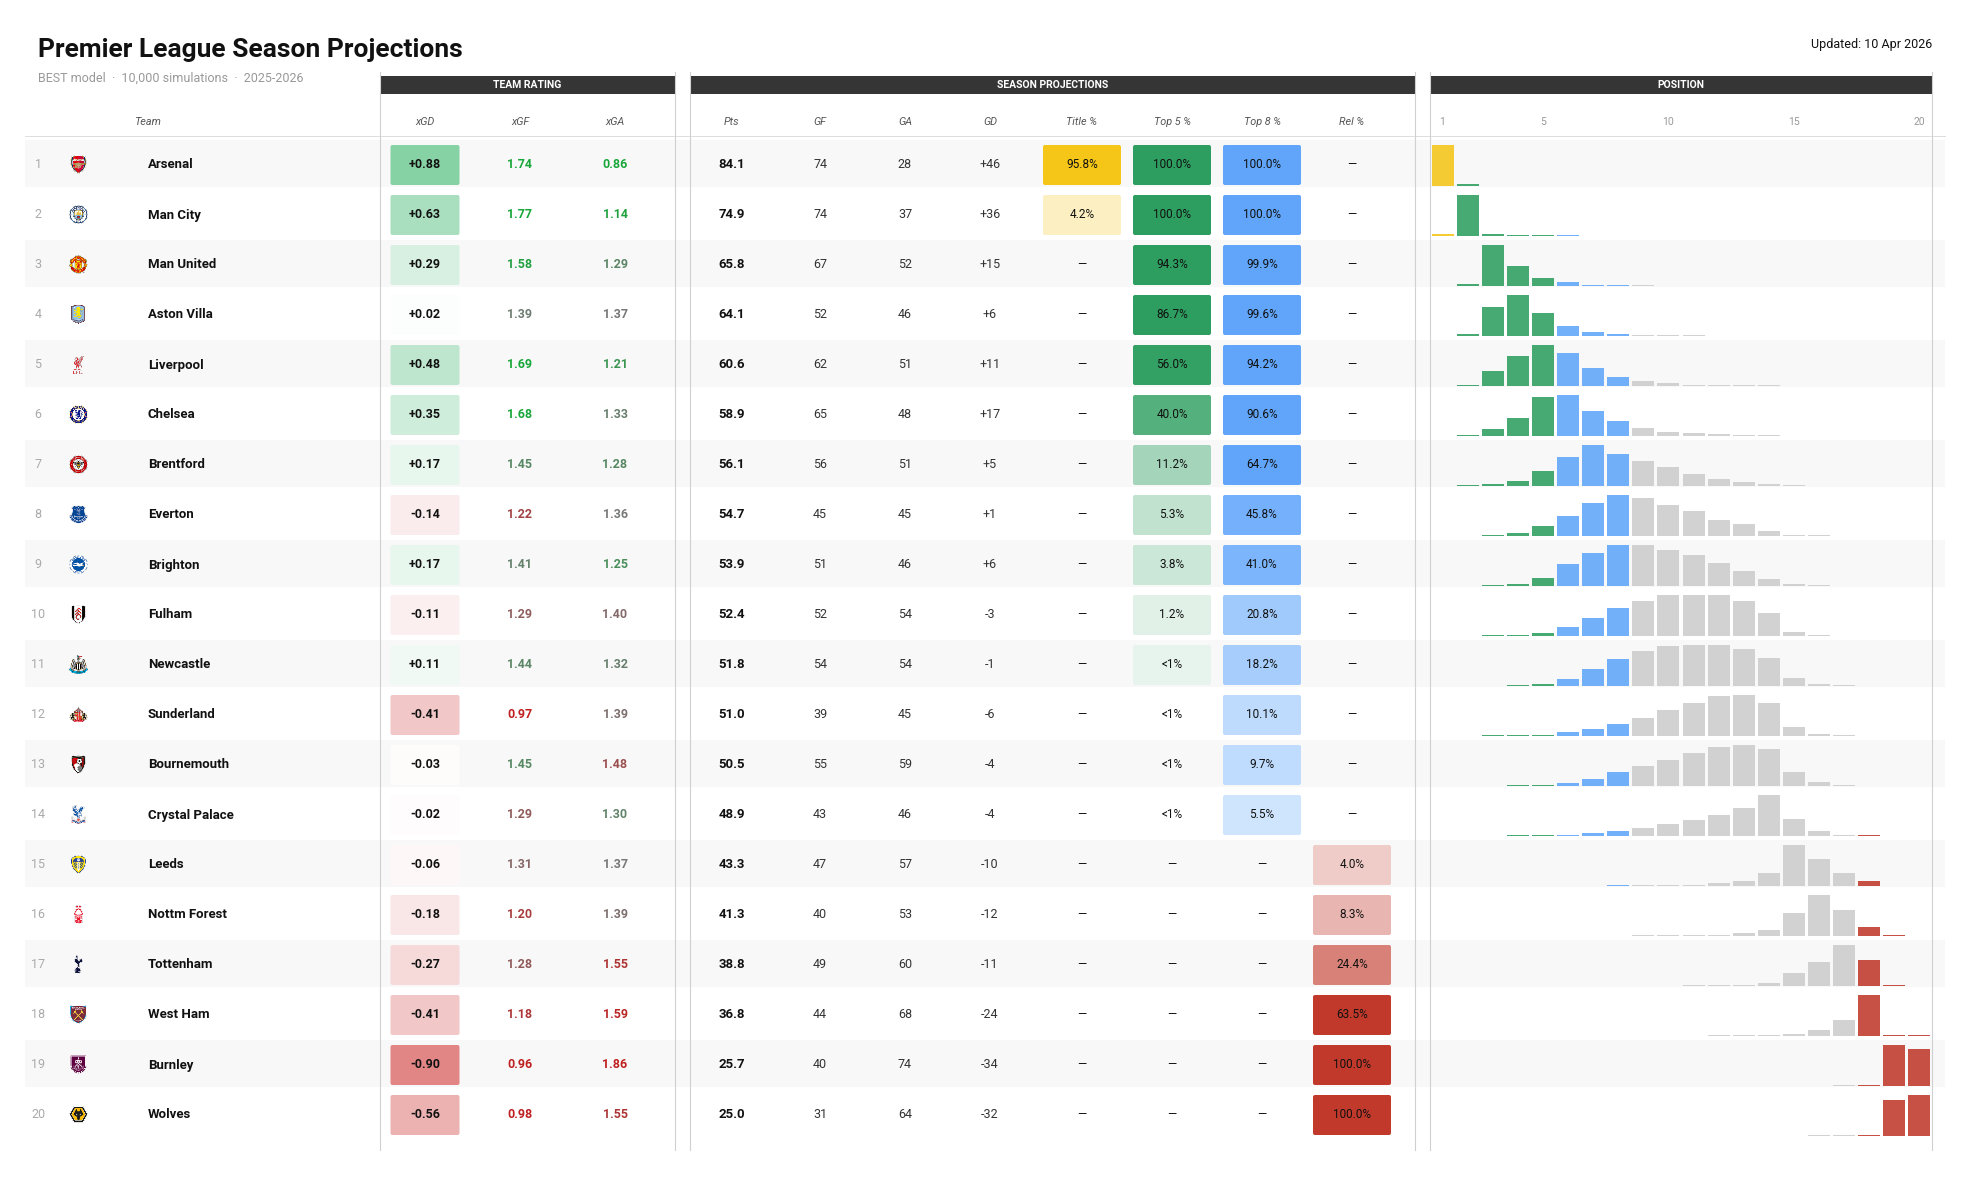

In [8]:
# ── 538-style combined table ──────────────────────────────────────────────────
fig = render_combined_table(
    avg_table     = avg_table,
    position_freq = position_freq,
    ratings_df    = ratings_df,
    n_sims        = N_SIMS,
    season        = SEASON,
    team_logos    = team_logos,
)
plt.savefig(os.path.join(str(NOTEBOOK_DIR), 'outputs', 'best_table.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## Power rankings — short window + season simulation

In [9]:
# ── Power rankings — short window form ratings ───────────────────────────────
WINDOW_START = '2025-12-01'

pr_df, pr_map, pr_n = load_and_process_data(
    db_path=DB_PATH, league=LEAGUE, season=SEASON, start=WINDOW_START,
    decay_rate=0.025, goals_weight=GOALS_WEIGHT,
    xg_weight=XG_WEIGHT, psxg_weight=PSXG_WEIGHT, epv_weight=EPV_WEIGHT,
)
print(f'Window: {WINDOW_START} → latest  |  {pr_n} teams, {pr_df["match_id"].nunique()} matches')

pr_form = form_net_rating(pr_df)
pr_form['rank'] = range(1, len(pr_form) + 1)
pr_form

Window: 2025-12-01 → latest  |  20 teams, 179 matches


,gf_avg,ga_avg,net_rating,rank
home_team,,,,
Arsenal,1.722618,0.861872,0.860746,1
Man City,1.720340,1.054569,0.665771,2
Man United,1.477207,1.074544,0.402663,3
Brighton,1.362571,0.994388,0.368183,4
Liverpool,1.615316,1.321212,0.294104,5
Chelsea,1.599368,1.343410,0.255958,6
Brentford,1.440024,1.219457,0.220567,7
Bournemouth,1.412561,1.271162,0.141399,8
Fulham,1.408252,1.268902,0.139350,9


In [10]:
# Top 10 form teams
pr_form[['net_rating', 'rank']].head(10)

,net_rating,rank
home_team,,
Arsenal,0.860746,1
Man City,0.665771,2
Man United,0.402663,3
Brighton,0.368183,4
Liverpool,0.294104,5
Chelsea,0.255958,6
Brentford,0.220567,7
Bournemouth,0.141399,8
Fulham,0.139350,9


## HTML Power Rankings Export

Generates `substack_power_rankings.html`. Open in browser → Select All (Cmd+A) → Copy → Paste into Substack.

In [ ]:
# ── Form ratings: current window vs previous week ─────────────────────────────
df_form_current, _, _ = load_and_process_data(
    db_path=DB_PATH, league=LEAGUE, season=SEASON,
    start=FORM_START, end=FORM_END,
    decay_rate=0.025,
    goals_weight=GOALS_WEIGHT, xg_weight=XG_WEIGHT,
    psxg_weight=PSXG_WEIGHT, epv_weight=EPV_WEIGHT,
)
form_current = form_net_rating(df_form_current)
form_current['form_rank'] = range(1, len(form_current) + 1)

df_form_prev, _, _ = load_and_process_data(
    db_path=DB_PATH, league=LEAGUE, season=SEASON,
    start=FORM_START, end=FORM_PREV_END,
    decay_rate=0.025,
    goals_weight=GOALS_WEIGHT, xg_weight=XG_WEIGHT,
    psxg_weight=PSXG_WEIGHT, epv_weight=EPV_WEIGHT,
)
form_prev = form_net_rating(df_form_prev)
form_prev['prev_form_rank'] = range(1, len(form_prev) + 1)

form_merged = form_current.merge(
    form_prev[['prev_form_rank']], left_index=True, right_index=True, how='left'
)
print(form_merged[['net_rating', 'form_rank', 'prev_form_rank']].head(10))

# ── Actual standings ──────────────────────────────────────────────────────────
played = df_actual[df_actual['home_goals'].notna()].copy()
_teams = list(team_mapping.keys())
pts_d = {t: 0 for t in _teams}
gf_d  = {t: 0 for t in _teams}
ga_d  = {t: 0 for t in _teams}
for _, r in played.iterrows():
    h, a = r['home_team'], r['away_team']
    if h not in pts_d or a not in pts_d:
        continue
    hg, ag = int(r['home_goals']), int(r['away_goals'])
    gf_d[h] += hg; ga_d[h] += ag
    gf_d[a] += ag; ga_d[a] += hg
    if   hg > ag: pts_d[h] += 3
    elif ag > hg: pts_d[a] += 3
    else:         pts_d[h] += 1; pts_d[a] += 1

standings = pd.DataFrame({
    'team': _teams,
    'pts':  [pts_d[t] for t in _teams],
    'gf':   [gf_d[t]  for t in _teams],
    'ga':   [ga_d[t]  for t in _teams],
    'gd':   [gf_d[t] - ga_d[t] for t in _teams],
}).sort_values(['pts', 'gd', 'gf'], ascending=False).reset_index(drop=True)
standings['table_pos'] = range(1, len(standings) + 1)

# ── Ratings ranks ─────────────────────────────────────────────────────────────
ratings_ranked = ratings_df.copy()
ratings_ranked['att_rank'] = ratings_ranked['goals_for'].rank(ascending=False).astype(int)
ratings_ranked['def_rank'] = ratings_ranked['goals_against'].rank(ascending=True).astype(int)
print(standings[['team', 'pts', 'gd', 'table_pos']].to_string(index=False))

In [ ]:
# ── Generate Substack HTML ────────────────────────────────────────────────────
output_html = os.path.join(str(NOTEBOOK_DIR), 'outputs', 'substack_power_rankings.html')
render_html_export(
    form_merged    = form_merged,
    standings      = standings,
    ratings_ranked = ratings_ranked,
    team_logos     = team_logos,
    df_actual      = df_actual,
    form_end       = FORM_END,
    output_path    = output_html,
    get_last_result = get_last_result,
    get_form_string = get_form_string,
    rank_arrow      = rank_arrow,
)

## Ratings evolution — GW5 onwards

Fits the model after each gameweek and tracks how team strengths change across the season.

**Runtime note:** at 20k/10k draws this loop takes a while (~15 min per GW).
Lower `N_SAMPLES_EVOLUTION` in the setup cell if you want it faster.

In [ ]:
# Identify gameweek cutoff dates — each GW = 10 matches (robust to festive fixture congestion)
match_df_evo, _, _, _ = load_football_data(DB_PATH, LEAGUE, SEASON)
played_evo = match_df_evo[match_df_evo['home_goals'].notna()].copy()
played_evo['match_date'] = pd.to_datetime(played_evo['match_date'])
played_evo = played_evo.sort_values('match_date').reset_index(drop=True)

MATCHES_PER_GW = 10
gw_cutoffs = []
for start in range(0, len(played_evo), MATCHES_PER_GW):
    chunk = played_evo.iloc[start:start + MATCHES_PER_GW]
    gw_cutoffs.append(chunk['match_date'].max().date())

print(f'{len(gw_cutoffs)} gameweeks detected')
print(f'GW1 end: {gw_cutoffs[0]}   GW5 end: {gw_cutoffs[4]}   Last GW: {gw_cutoffs[-1]}')


In [ ]:
# Consistent team index across all GW iterations
all_teams = sorted(set(played_evo['home_team'].unique()) | set(played_evo['away_team'].unique()))
full_map  = {t: i for i, t in enumerate(all_teams)}
n_all     = len(all_teams)

from manual_priors import MANUAL_ATT_PRIORS, MANUAL_DEF_PRIORS

def fit_gw(cutoff_date):
    """Fit the same model as the main run, on data up to cutoff_date."""
    gw_df, _, _ = load_and_process_data(
        db_path=DB_PATH, league=LEAGUE, season=SEASON,
        end=cutoff_date,
        decay_rate=DECAY_RATE, goals_weight=GOALS_WEIGHT,
        xg_weight=XG_WEIGHT, psxg_weight=PSXG_WEIGHT, epv_weight=EPV_WEIGHT,
    )
    # Override indices to use the full consistent team list
    gw_df = gw_df.copy()
    gw_df['home_idx'] = gw_df['home_team'].map(full_map).astype(int)
    gw_df['away_idx'] = gw_df['away_team'].map(full_map).astype(int)

    _, tr = build_and_sample_model(
        gw_df, n_all,
        trace=N_SAMPLES_EVOLUTION, tune=N_TUNE_EVOLUTION,
        team_mapping=full_map,
        manual_att_priors=MANUAL_ATT_PRIORS,
        manual_def_priors=MANUAL_DEF_PRIORS,
    )
    post = tr.posterior
    return (
        post['att_str'].values.reshape(-1, n_all).mean(axis=0),
        post['def_str'].values.reshape(-1, n_all).mean(axis=0),
    )

# Run from GW5 onwards (index 4)
evo_records = []
for gw_num, cutoff in enumerate(gw_cutoffs[4:], start=5):
    print(f'GW{gw_num} ({cutoff})...', end=' ', flush=True)
    att_means, def_means = fit_gw(cutoff)
    for i, team in enumerate(all_teams):
        evo_records.append({
            'gw':      gw_num,
            'date':    cutoff,
            'team':    team,
            'att':     att_means[i],
            'def':     def_means[i],
            'net':     att_means[i] - def_means[i],
        })
    print('done')

evo_df = pd.DataFrame(evo_records)
print(f'Evolution data: {len(evo_df)} rows')

In [ ]:
for metric in ['net', 'att', 'def']:
    fig = render_evo_chart(evo_df, metric=metric, season=SEASON, league='Premier League',
        save_path=os.path.join(str(NOTEBOOK_DIR), 'outputs', f'evo_{metric}.png'))
    plt.show()